In [3]:
from pandas import read_csv
from matplotlib import pyplot

In [4]:

from google.colab import drive
drive.mount('/content/drive')
DATA_DIRS = "drive/MyDrive/PRED_TRAFFIC/nb_variable_utilisateurs/"
!cd drive/MyDrive/PRED_TRAFFIC/nb_variable_utilisateurs/
!ls drive/MyDrive/PRED_TRAFFIC/nb_variable_utilisateurs/scenario1
import pandas as pd
import numpy as np

data = pd.read_csv("drive/MyDrive/PRED_TRAFFIC/nb_variable_utilisateurs/scenario4/rx_throughput.csv", sep=';')

/bin/bash: line 0: cd: drive/MyDrive/PRED_TRAFFIC/nb_variable_utilisateurs/: No such file or directory
ls: cannot access 'drive/MyDrive/PRED_TRAFFIC/nb_variable_utilisateurs/scenario1': No such file or directory


FileNotFoundError: ignored

In [4]:

data= data[data['throughput (kbps)'] != 0] #delete zeros
data = data.rename(columns = {'throughput (kbps)': 'debit'})

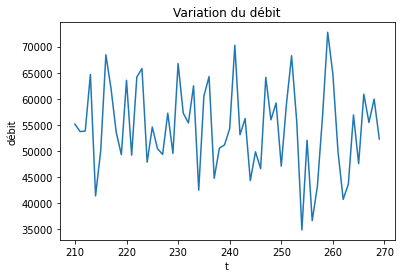

In [5]:
import matplotlib.pyplot as plt

f, ax = plt.subplots(1,1)

ax.plot(data['debit'][200:260])
# Add title
ax.set(xlabel='t', ylabel='débit')
ax.set_title('Variation du débit')

# Show graph
plt.show()
plt.close()




In [6]:
from statsmodels.tsa.stattools import adfuller
def test_stationarity(data, ts):
    rolmean = data[ts].rolling(window = 8, center = False).mean()
    rolstd = data[ts].rolling(window = 8, center = False).std()
    
    # Plot rolling statistics:
    orig = plt.plot(data[ts][:400], 
                    color = 'blue', 
                    label = 'Original')
    mean = plt.plot(rolmean[:400], 
                    color = 'red', 
                    label = 'Rolling Mean')
    std = plt.plot(rolstd[:400], 
                   color = 'black', 
                   label = 'Rolling Std')
    plt.legend(loc = 'best')
    plt.title('Rolling Mean & Standard Deviation for %s' %(ts))
    plt.xticks(rotation = 45)
    plt.show(block = False)
    plt.close()
    
    # Perform Dickey-Fuller test:
    # (H_0) :La série n'est pas stationnaire
    # (H_1): La série est stationnaire
    print('Results of Dickey-Fuller Test of %f :', ts)
    dftest = adfuller(data[ts], 
                      autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], 
                         index = ['Test Statistic',
                                  'p-value',
                                  '# Lags Used',
                                  'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    
    print(dfoutput)
def plot_transformed_data(df, ts, ts_transform, a=100, b=150):
  f, ax = plt.subplots(1,1)
  ax.plot(df[ts][a:b])
  ax.plot(df[ts_transform][a:b], color = 'red')

  # Add title
  ax.set_title('%s and %s time-series graph' %(ts, ts_transform))

  # Rotate x-labels
  ax.tick_params(axis = 'x', rotation = 45)

  # Add legend
  ax.legend([ts, ts_transform])
  
  plt.show()
  plt.close()

  return

/usr/local/lib/python3.7/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


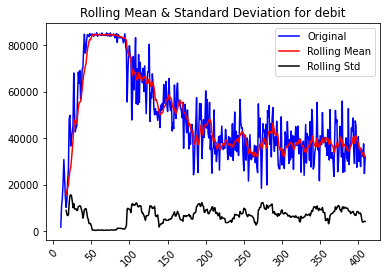

Results of Dickey-Fuller Test of %f : debit
Test Statistic                   -23.997272
p-value                            0.000000
# Lags Used                       49.000000
Number of Observations Used    71939.000000
Critical Value (1%)               -3.430441
Critical Value (5%)               -2.861580
Critical Value (10%)              -2.566791
dtype: float64


In [25]:
test_stationarity(data,ts = 'debit')

In [2]:
# Transformation - log 
data['debit_log'] = data['debit'].apply(lambda x: np.log(x))

# Transformation - 7-t moving averaeges of log ts
data['debit_log_moving_avg'] = data['debit_log'].rolling(window = 4,
                                                               center = False).mean()

data['debit_moving_avg'] = data['debit'].rolling(window = 7,
                                                       center = False).mean()



data_transform = data.dropna()
display(data_transform.head())


NameError: ignored

In [1]:
def lstm_model(df, 
                  ts, 
                  look_back, 
                  epochs, 
                  type_ = None, 
                  train_fraction = 0.67):
  import math
  from keras.models import Sequential
  from keras.layers import Dense
  from keras.layers import LSTM
  from sklearn.preprocessing import MinMaxScaler
  from keras.utils.vis_utils import plot_model
  from sklearn.metrics import mean_squared_error

  def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset)-look_back-1):
      a = dataset[i:(i+look_back), 0]
      dataX.append(a)
      dataY.append(dataset[i + look_back, 0])
    return np.array(dataX), np.array(dataY)

  np.random.seed(7)

  dataset = df[ts].values
  dataset = dataset.astype('float32')
  #normalisation des données
  scaler = MinMaxScaler(feature_range=(0, 1))
  dataset = scaler.fit_transform(dataset.reshape(-1, 1))
  
  train_size = int(len(dataset) * train_fraction)
  test_size = len(dataset) - train_size
  train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]
  
  trainX, trainY = create_dataset(train, look_back)
  testX, testY = create_dataset(test, look_back)
  
  # Reshape to  [samples, time steps, features]
  
  trainX = np.reshape(trainX, (trainX.shape[0], 1, trainX.shape[1]))
  testX = np.reshape(testX, (testX.shape[0], 1, testX.shape[1]))
  
  batch_size = 1
  model = Sequential()
    
  model.add(LSTM(4, input_shape=(1, look_back)))
  
  model.add(Dense(1))
  print(model.summary())
  plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)
  model.compile(loss='mean_squared_error', optimizer='adam')
  model.fit(trainX, 
              trainY, 
              epochs = epochs, 
              batch_size = 1, 
              verbose = 2)

  trainPredict = model.predict(trainX)
  testPredict = model.predict(testX)

  trainPredict = (scaler.inverse_transform(trainPredict))
  trainY = (scaler.inverse_transform([trainY]))
  testPredict = (scaler.inverse_transform(testPredict))
  testY = (scaler.inverse_transform([testY]))
  
  # Calculate root mean squared error
  trainScore = math.sqrt(mean_squared_error(trainY[0], trainPredict[:,0]))
  print('Train Score: %.2f RMSE' % (trainScore))
  testScore = math.sqrt(mean_squared_error(testY[0], testPredict[:,0]))
  print('Test Score: %.2f RMSE' % (testScore))
  
  # Shift train predictions for plotting
  trainPredictPlot = np.empty_like(dataset)
  trainPredictPlot[:, :] = np.nan
  trainPredictPlot[look_back:len(trainPredict)+look_back, :] = trainPredict
  
  testPredictPlot = np.empty_like(dataset)
  testPredictPlot[:, :] = np.nan
  testPredictPlot[len(trainPredict)+(look_back*2)+1:len(dataset)-1, :] = testPredict
  plt.plot(scaler.inverse_transform(dataset))
  plt.plot(trainPredictPlot)
  plt.plot(testPredictPlot)
  plt.show()
  plt.close()
  
  return



Model: "sequential_7"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm_7 (LSTM)                (None, 4)                 240       
_________________________________________________________________
dense_7 (Dense)              (None, 1)                 5         
Total params: 245
Trainable params: 245
Non-trainable params: 0
_________________________________________________________________
None
Epoch 1/3
48217/48217 - 60s - loss: 0.0027
Epoch 2/3
48217/48217 - 58s - loss: 0.0020
Epoch 3/3
48217/48217 - 58s - loss: 0.0020
Train Score: 0.07 RMSE
Test Score: 0.07 RMSE


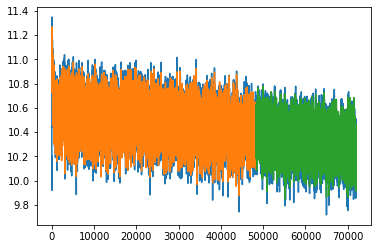

In [27]:

lstm_model(df = data_transform, 
              ts = 'debit_log_moving_avg', 
              look_back = 10,
              epochs = 3
              )


NameError: ignored

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm_2 (LSTM)                (None, 4)                 160       
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 5         
Total params: 165
Trainable params: 165
Non-trainable params: 0
_________________________________________________________________
None
Train Score: 0.81 RMSE
Test Score: 0.64 RMSE


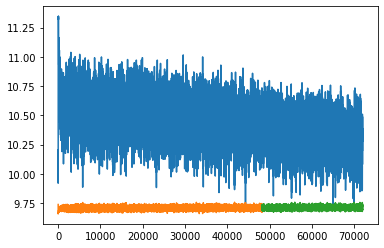

In [12]:
lstm_model(df = data_transform, 
              ts = 'debit_log_moving_avg', 
              look_back = 5, 
              epochs = 5)

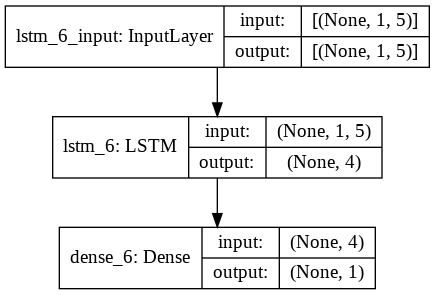

In [43]:

import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread('model_plot.png') 
  
cv2_imshow(img)